### Dimensionality Reduction

## Problem 1


### Task 1:

Show mathematically how PCA reduces the dimensionality of data using the covariance matrix and eigenvectors.


Consider a centered data matrix $X$ where $X \epsilon \mathbb{R}^{n \times d}$ and $n$ is the number of samples, $d$ is the number of features. 

The covariance matrix of $X$ is computed as $C = \frac{1}{n-1}X^TX$, and the matrix results in a size $d \times d$.

Eigenvectors ($V$) and eigenvalues ($\lambda$) are decomposed by solving $Cv = \lambda v$, where the eigenvector represents the direction of the vata and the eigenvalue showcases the variance. The eigenvalues, using the eigenvectors, are ordered from largest to smallest, and the top number of eigenvectors defined by PCA ($W_k = [v_1, ... v_k]$) are chosen to reduce the PCA space to that size ($X_{transformed} = XW$).

### Task 2:


Given the covariance matrix of a 2D dataset:

$$
C = \begin{bmatrix}
4 & 2 \\
2 & 3
\end{bmatrix},
$$

Calculate the eigenvalues and eigenvectors manually. Identify the principal components.

Eigenvalues are found using the theory that $\text{det}(C - \lambda I) = 0$.

Therefore,

$\text{det} \begin{bmatrix} 4 - \lambda & 2 \\ 2 & 3 - \lambda \end{bmatrix} = 0$

$(4 - \lambda)(3 - \lambda) - (2)(2) = 0$

$12 - 3\lambda - 4\lambda + \lambda^2 - 4 = 0$

$\lambda^2 - 7\lambda + 8 = 0$

Using the quadratic formula,

$\lambda = \frac{7 \pm \sqrt{49 - 32}}{2} = \frac{7 \pm \sqrt{17}}{2}$

So $\lambda_1 = \frac{7 + \sqrt{17}}{2}$ and $\lambda_2 = \frac{7 - \sqrt{17}}{2}$.

The eigenvectors are calculated using the first row of the covariance matrix, multiplied by a vector $\begin{bmatrix} x \\y \end{bmatrix}$.

### For $\lambda_1 = \frac{7 + \sqrt{17}}{2}$, 

$(4-\lambda)x + 2y = 0$

$2y = (\lambda - 4)x$

$y = \frac{(\lambda - 4)x}{2}$

For $\lambda - 4 \rightarrow \frac{7 + \sqrt{17}}{2} - 4 = \frac{7 + \sqrt{17}}{2} - \frac{8}{2} = \frac{-1 + \sqrt{17}}{2}$

$y = \frac{-1 + \sqrt{17}}{2 \times 2}x = \frac{-1 + \sqrt{17}}{4}x$

Let $x = 4 \rightarrow y = -1 + \sqrt{17} = \sqrt{17} - 1 \rightarrow \begin{bmatrix}4 \\ \sqrt{17}-1 \end{bmatrix} \approx \begin{bmatrix}4 \\ 3.12 \end{bmatrix} \approx \begin{bmatrix}1 \\ 0.78 \end{bmatrix}$

Computing the norm, $\parallel v_1 \parallel = \sqrt{1^2 + 0.78^2} \approx \sqrt{1.6084} \approx 1.268$

$\hat{v}_2 = \frac{1}{1.268}\begin{bmatrix} 1\\ 0.78\end{bmatrix} \approx \begin{bmatrix}0.788 \\ 0.615 \end{bmatrix}$

### For $\lambda_2 = \frac{7 - \sqrt{17}}{2}$, 

$(4-\lambda)x + 2y = 0$

$2y = (\lambda - 4)x$

$y = \frac{(\lambda - 4)x}{2}$

For $\lambda - 4 \rightarrow \frac{7 - \sqrt{17}}{2} - 4 = \frac{7 - \sqrt{17}}{2} - \frac{8}{2} = \frac{-1 - \sqrt{17}}{2}$

$y = \frac{-1 - \sqrt{17}}{2 \times 2}x = \frac{-1 - \sqrt{17}}{4}x$

Let $x = 4 \rightarrow y = -1 - \sqrt{17} = -\sqrt{17} - 1 \rightarrow \begin{bmatrix}4 \\ -\sqrt{17}-1 \end{bmatrix} \approx \begin{bmatrix}4 \\ -5.12 \end{bmatrix} \approx \begin{bmatrix}1 \\ -1.28 \end{bmatrix}$

Computing the norm, $\parallel v_2 \parallel = \sqrt{1^2 + -1.28^2} \approx \sqrt{2.6384} \approx 1.624$

$\hat{v}_2 = \frac{1}{1.624}\begin{bmatrix} 1\\ -1.28\end{bmatrix} \approx \begin{bmatrix}0.625 \\ -0.788 \end{bmatrix}$

### Determining the Principal Components

The principal components are determined by the eigenvector, ordered by the largest eigenvalue.

Since $\lambda_1 = \frac{7 + \sqrt{17}}{2} \gt \lambda_2 = \frac{7 - \sqrt{17}}{2}$,

PC1 is $\begin{bmatrix}0.788 \\ 0.615 \end{bmatrix}$ and PC2 is $\begin{bmatrix}0.625 \\ -0.788 \end{bmatrix}$.

### Task 3:


Now write Python code step-by-step to perform the same tasks as in task 2 using code. Does your answer agree with what you obtained in task 2? Why?

In [ ]:
import numpy as np

C = np.array([[4, 2], [2, 3]])

eigenvalues, eigenvectors = np.linalg.eig(C)

# Sort the eigenvalues and eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

# Select the principal components from ascending to descending order
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]
print("Principal Component 1:", pc1)
print("Principal Component 2:", pc2)

Eigenvalues: [5.56155281 1.43844719]
Eigenvectors:
 [[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]
Principal Component 1: [0.78820544 0.61541221]
Principal Component 2: [-0.61541221  0.78820544]


Considering a sign change on principal component 2 using NumPy, the eigenvalues and eigenvectors are consistent. The principal components are chosen from the largest eigenvalue first, matching the manual calculation. The signs of the eigenvectors do not matter in PCA as they can be multiplied by -1 to reverse the sign.

## Problem 2

### Task 1:


Load the MNIST handwritten digits dataset (use `sklearn.datasets.fetch_openml`) and:
- Apply PCA to reduce the data from 784 dimensions to 2 dimensions for visualization.
- Plot the 2D representation of the digits, coloring points by their digit labels.

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
mnist = fetch_openml(data_id=554)  # Load the MNIST dataset

X = mnist.data.to_numpy().astype(float)  # Convert data to float
y = mnist.target.to_numpy().astype(int)  # Convert target labels to integers (used for indexing)

print("Shape of X:", X.shape)

Shape of X: (70000, 784)


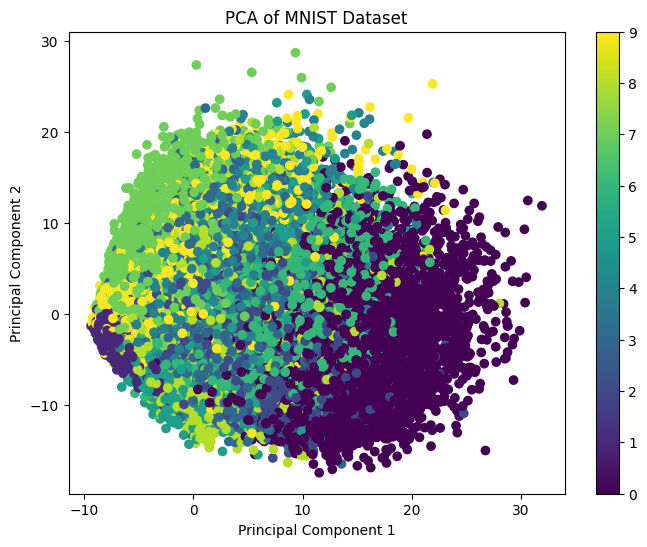

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Dataset')
plt.colorbar()
plt.show()

### Task 2:


Compute and plot the cumulative explained variance as a function of the number of principal components. How many components are needed to retain 95% of the variance?

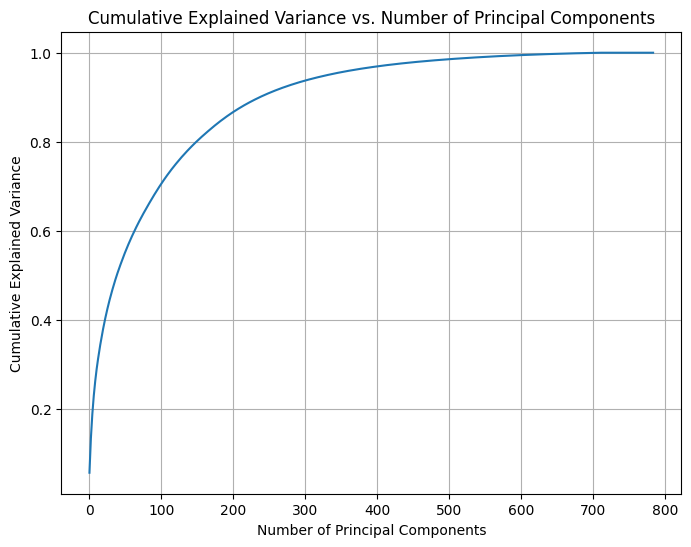

Number of principal components to retain 95% variance: 332


In [ ]:
# Calculate the cumulative explained variance - PCA must be applied to all components
pca_full = PCA()
X_pca_full  = pca_full.fit_transform(X_scaled)
explained_variance = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance)

# Plot the cumulative explained variance
plt.figure(figsize=(8, 6))
plt.plot(cumulative_explained_variance)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Principal Components')
plt.grid()
plt.show()

# Get the 95% explained varience component number
n_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of principal components to retain 95% variance: {n_components_95}")

### Task 3:

Reconstruct the digit images using only the top 50 principal components. 
- Visualize 5 original images and their reconstructed counterparts side-by-side.
- Discuss the quality of the reconstruction.


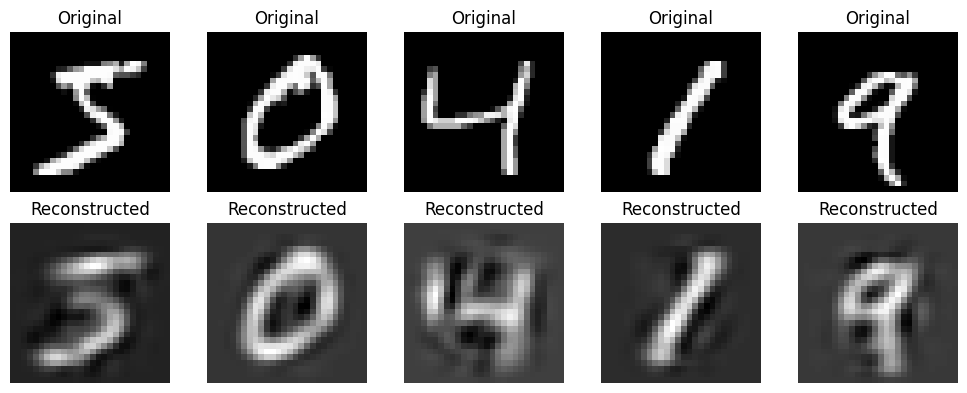

In [ ]:
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_scaled)

X_50_reconstructed = pca_50.inverse_transform(X_pca_50)
X_50_reconstructed = scaler.inverse_transform(X_50_reconstructed)

# Display original and reconstructed images
n_images = 5
plt.figure(figsize=(10, 4))
for i in range(n_images):
    # Original image
    plt.subplot(2, n_images, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstructed image
    plt.subplot(2, n_images, i + 1 + n_images)
    plt.imshow(X_50_reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

The reconstruction on the images were fairly accurate other than the digit 4, which was less acceptable in quality than the rest. While knowing that the iamges are numerical digits, it can be understood what the images represent. However, the reconstruction considers some background color that muddles the quality of the number.

### Task 4:


Use cat pictures in the [Animal faces dataset](https://www.kaggle.com/datasets/andrewmvd/animal-faces), covert them into black and white. Then apply PCA and visualize the first five most important components. Briefly describe what they represent.

Shape of cat_images: (5153, 4096)


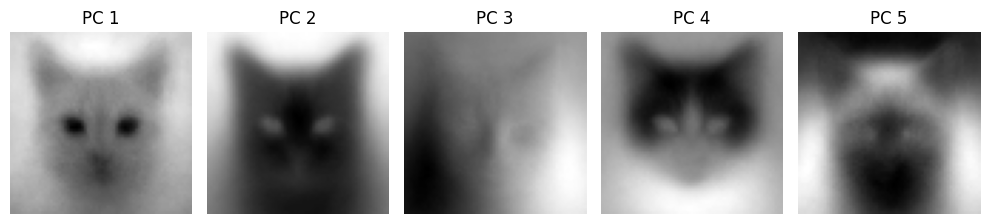

In [ ]:
import cv2
import os

cat = "afhq/train/cat"
# Resize images for better processing
img_size = (64, 64)

# Convert the cat images to grayscale and flatten them
cat_images = []
for filename in os.listdir(cat):
    if filename.endswith(".jpg"):
        path = os.path.join(cat, filename)
        # Read the image in grayscale
        img = cv2.imread(path, 0)
        # Resize the image
        img_resized = cv2.resize(img, img_size)
        cat_images.append(img_resized.flatten())

cat_images = np.array(cat_images)
print("Shape of cat_images:", cat_images.shape)

# Apply PCA to the cat images
pca_cat = PCA(n_components=5)
cat_images_pca = pca_cat.fit(cat_images)

# Visualize the first five most important components
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(pca_cat.components_[i].reshape(64, 64), cmap='gray')
    plt.title(f'PC {i + 1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

Each PCA component may represent different aspects of a cat picture. From what it seems like, PC 1 showcases the general cat face shape, PC 2 focuses on the coat color, PC 3 determines the lighting of the photo, and PC 4 and 5 determine certain features such as marks, coat contrasts, etc.

## Problem 3

### Task 1:

Here, we use the `scipy.io.wavfile` library to load two real-world audio signals (e.g., speech and music). We then mix these signals using a custom mixing matrix.

Your task is to apply ICA (feel free to use `sklearn's FastICA`) to the mixed signals to recover the original sources.

Here is a starter code for you. Note that you should have either downloaded (e.g. from [here](https://freesound.org/)) or recorded audio files on your path.

In [ ]:
# Uncomment this code block and run
from scipy.io import wavfile
import numpy as np

# Load audio files
rate1, signal1 = wavfile.read('audio1.wav')
rate2, signal2 = wavfile.read('audio2.wav')

# Resample and mix signals
min_len = min(len(signal1), len(signal2))
signal1, signal2 = signal1[:min_len], signal2[:min_len]
S = np.c_[signal1, signal2]

A = np.array([[1, 0.5], [0.5, 1]])  # Mixing matrix
X = S @ A.T  # Mixed signals

/var/folders/j4/5vsg2ml56gl_twrrbcv64g2w0000gn/T/ipykernel_23704/2774852299.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate2, signal2 = wavfile.read('audio2.wav')


In [ ]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2)
# Reconstruct signals
signals_reconstructed = ica.fit_transform(X)
# Get estimated mixing matrix
ica_mixing = ica.mixing_

print("Estimated mixing matrix:\n", ica_mixing)

Estimated mixing matrix:
 [[2070.91080773 2954.07066995]
 [1022.59392551 5898.71647774]]


### Task 2:

Evaluate the quality of separation. For this purpose, plot the waveforms of the original signals, mixed signals, and recovered signals.
Discuss any limitations in the separation (e.g., noise, artifacts).


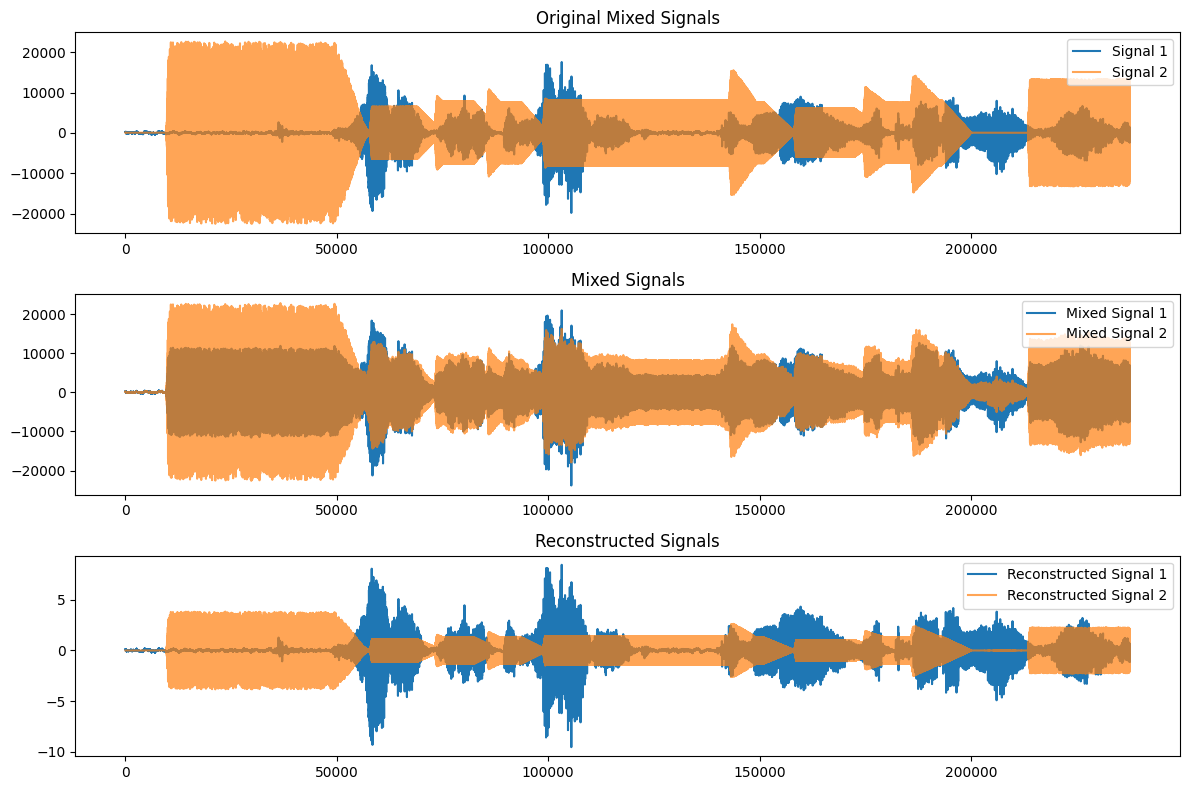

In [ ]:
# Plot original, mixed signals, and reconstructed signals
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.title('Original Mixed Signals')
# Plot separately for better visualization
plt.plot(S[:, 0], label='Signal 1')
plt.plot(S[:, 1], label='Signal 2', alpha=0.7)
plt.legend(['Signal 1', 'Signal 2'], loc='upper right')
plt.tight_layout()

plt.subplot(3, 1, 2)
plt.title('Mixed Signals')
plt.plot(X[:, 0], label='Mixed Signal 1')
plt.plot(X[:, 1], label='Mixed Signal 2', alpha=0.7)
plt.legend(['Mixed Signal 1', 'Mixed Signal 2'], loc='upper right')
plt.tight_layout()

plt.subplot(3, 1, 3)
plt.title('Reconstructed Signals')
plt.plot(signals_reconstructed[:, 0], label='Reconstructed Signal 1')
plt.plot(signals_reconstructed[:, 1], label='Reconstructed Signal 2', alpha=0.7)
plt.legend(['Reconstructed Signal 1', 'Reconstructed Signal 2'])
plt.tight_layout()
plt.show()

Signal 1 represents the audio signal of a man speaking, and signal 2 represents a synth playing a song. The original signals are plotted in the first subplot. The mixed signal subplot mixes the first signal to closer match the second. When ICA is used to reconstruct the signals, signal 1 is similar to the original, and signal 2 seems to be a more compressed version. It also seems like the noise of signal 1 was slightly amplified when reconstructed.

## Problem 4

### Task 1:

Generate a synthetic dataset with three clusters in the shape of:
- Two interlocking moons (using sklearn.datasets.make_moons).
- A circular cluster (using sklearn.datasets.make_circles).
Combine the datasets and apply spectral clustering to segment the data. Use a similarity graph based on nearest neighbors.

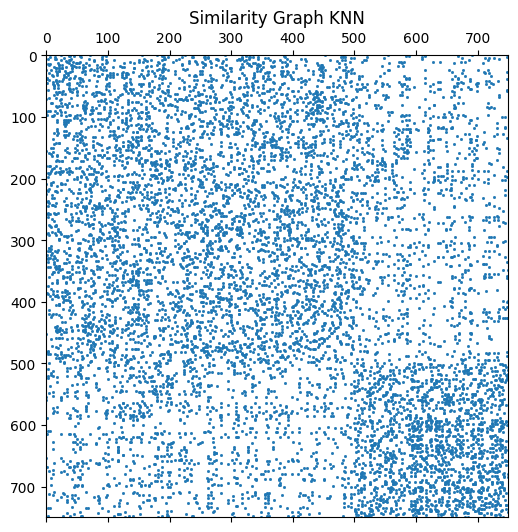

In [ ]:
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.neighbors import kneighbors_graph


# Two interlocking moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)
# One circular cluster
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
circle_cluster = X_circles[y_circles == 0] # Extract the outer circular cluster

# Combine datasets
X = np.vstack((X_moons, circle_cluster))

# Spectral Clustering
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
labels = spectral.fit_predict(X)

# Similarity Graph
similarity_graph = kneighbors_graph(X, n_neighbors=12, include_self=False)
plt.figure(figsize=(8, 6))
plt.spy(similarity_graph, markersize=1)
plt.title('Similarity Graph KNN')
plt.show()

### Task 2: 

Visualize the original clusters and the clusters predicted by spectral clustering. Compare the performance of spectral clustering with K-means. Which performs better, and why?

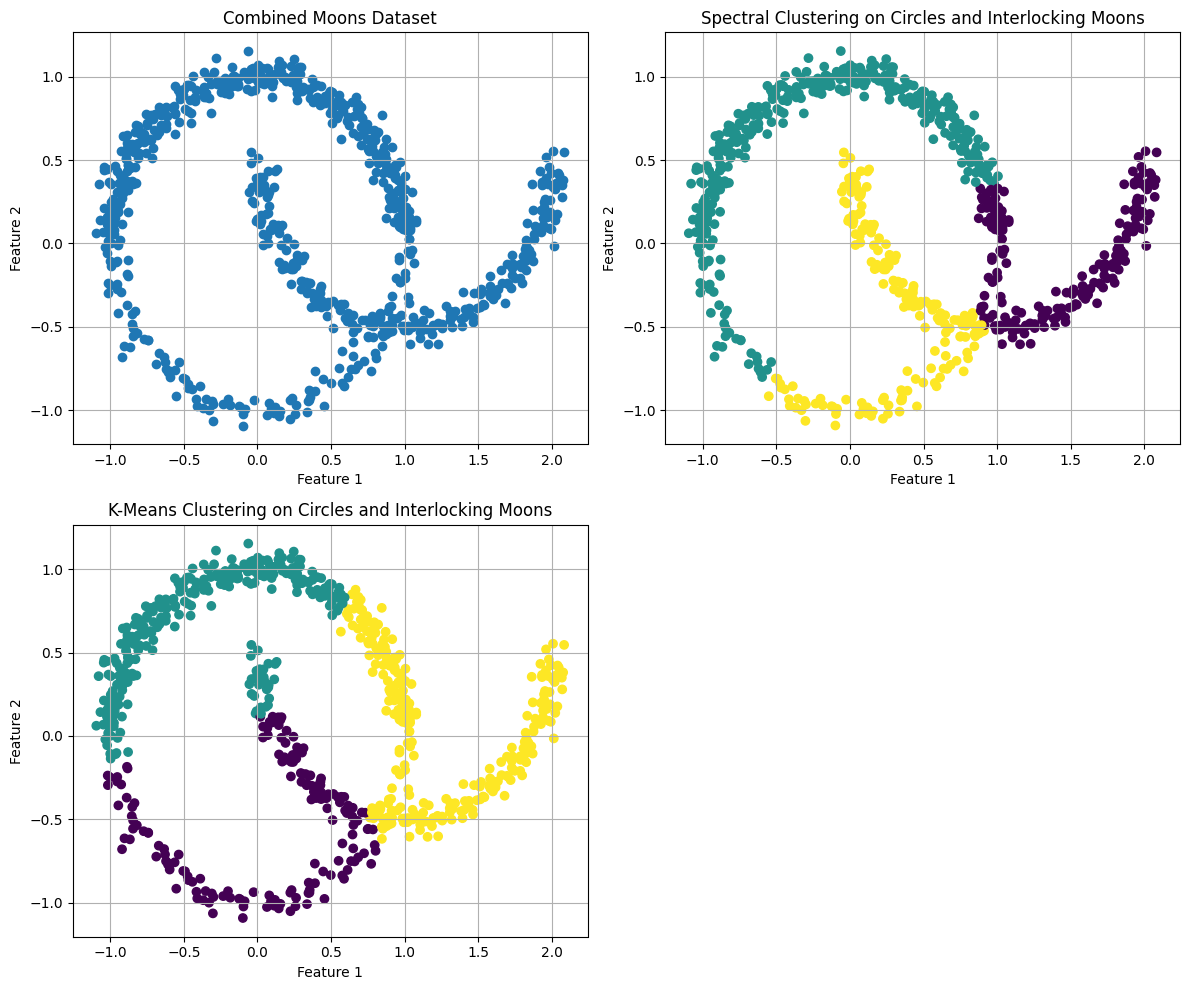

In [ ]:
# Plot the original combined moons dataset
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.title('Combined Moons Dataset')
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()

# Plot the Spectral clusters
plt.subplot(2, 2, 2)
plt.title('Spectral Clustering on Circles and Interlocking Moons')
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()

# Create and plot K-Means clusters - assuming this is the correct interpretation of the question
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
plt.subplot(2, 2, 3)
plt.title('K-Means Clustering on Circles and Interlocking Moons')
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()

plt.tight_layout()
plt.show()

Comparing the performance of Spectral vs. K-Means clustering, the spectral clustering performs better. This is due to k-means assuming spherical clusters, which does not fit as well to non-linear data as well as spectral clustering does. Spectral clustering can capture the non-linear relationships because they are clustered based on the similarity between points instead of distances between centroids.